In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from polars.testing.parametric import columns
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import (
    WhiteKernel, ConstantKernel, RBF, RationalQuadratic, ExpSineSquared, DotProduct
)
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm

from src.data_loader import BondDataLoader
from src.feature_manager_sim import FeatureManagerSim
from src.feature_manager import FeatureManager
from src.kernel_ridge_models import KernelRidgeEnsemble
from src.walk_forward import WalkForwardValidator
from random import uniform
# import floor
from math import floor
# import time
import time

In [3]:
# n_samples = 1000000
# test_size = 31
# # round down
# max_train_size = floor((n_samples - (test_size * 3)) / 3)
# # max_train_size = min(1000, n_samples // 2)
# # test_size = min(31, n_samples // 10)
# # n_splits = min(3, max(2, n_samples // (max_train_size + test_size)))
# print(f"Number of splits: {n_splits}")
# print(f"Max train size: {max_train_size}")
# print(f"Test size: {test_size}")
# uniform(0.0001, 0.1)
# np.percentile([1, 3, 5, 99], 99)

In [11]:
n_samples // 2

50000000

In [18]:
# get the target, actual, and feature columns
feature_manager = FeatureManagerSim(features_config_path='data/features_selected4.yaml')
feature_manager2 = FeatureManager(features_config_path='data/features_selected3.yaml')
independent_variables = feature_manager2.get_features_for_time_pred(time_prediction='seven-day-ahead')
dependent_variables = feature_manager.get_dependent_variables(time_prediction='seven-day-ahead')
actuals_variables = feature_manager.get_actual_variables()

# print the outputs
print(f"Independent variables: {independent_variables}")
dependent_variable_new = [f"{x}_future_val" for x in dependent_variables]
print(f"Dependent variables: {dependent_variable_new}")
print(f"Actual variables: {actuals_variables}")

raw_data = pd.read_parquet('data/kernel_regression_train_shifted_7_.parquet')
raw_data[feature_manager2.get_dependent_variables()].head()
# drop duplicate columns
# raw_data = raw_data.T.drop_duplicates().T

INFO:src.feature_manager_sim:Loaded features for 6 future time predictions
INFO:src.feature_manager_sim:Available time predictions: ['seven-day-ahead', 'sixty-day-ahead', 'future_values', 'current_values', 'thirty-day-ahead', 'one-day-ahead']
INFO:src.feature_manager:Loaded features for 5 future time predictions
INFO:src.feature_manager:Available time predictions: ['seven-day-ahead', 'dependent_variables', 'sixty-day-ahead', 'thirty-day-ahead', 'one-day-ahead']
INFO:src.feature_manager:Retrieved 18 features for seven-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 dependent variables for seven-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 actual variables


Independent variables: ['U6RATE', 'MEDCPIM157SFRBCLE_moving_avg_60', 'STICKCPIM158SFRBATL_moving_avg_60', 'DGS5', 'DGS7', 'DGS10', 'DGS3', 'DGS3MO', 'DGS1', 'DGS30', 'REAINTRATREARAT1YE_moving_avg_60', 'DGS6MO', 'REAINTRATREARAT1YE_exp_moving_avg_60', 'MEDCPIM157SFRBCLE_exp_moving_avg_60', 'U6RATE_exp_moving_avg_60', 'DGS20', 'DGS1MO', 'DGS2']
Dependent variables: ['DGS1MO_future_val', 'DGS3MO_future_val', 'DGS6MO_future_val', 'DGS1_future_val', 'DGS2_future_val', 'DGS3_future_val', 'DGS5_future_val', 'DGS7_future_val', 'DGS10_future_val', 'DGS20_future_val', 'DGS30_future_val']
Actual variables: ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']


,DGS1MO_future_val,DGS3MO_future_val,DGS6MO_future_val,DGS1_future_val,DGS2_future_val,DGS3_future_val,DGS5_future_val,DGS7_future_val,DGS10_future_val,DGS20_future_val,DGS30_future_val
period,,,,,,,,,,,
2006-01-01,4.06,4.22,4.39,4.38,4.36,4.32,4.32,4.33,4.38,4.63,4.53
2006-01-02,4.09,4.23,4.40,4.39,4.36,4.32,4.32,4.34,4.38,4.63,4.53
2006-01-03,4.15,4.29,4.42,4.42,4.41,4.36,4.36,4.38,4.43,4.68,4.62
2006-01-04,4.16,4.30,4.45,4.44,4.44,4.39,4.39,4.41,4.46,4.70,4.61
2006-01-05,4.16,4.32,4.43,4.42,4.39,4.35,4.35,4.37,4.42,4.66,4.56


<Axes: xlabel='period', ylabel='DGS3MO_future_val'>

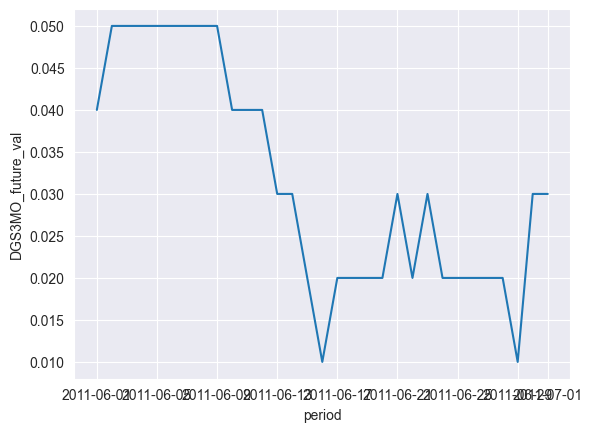

In [20]:
# raw_data[raw_data.index.to_timestamp() == pd.to_datetime('2006-01-')]
df_tmp = raw_data[(raw_data.index.to_timestamp() < pd.to_datetime('2011-07-02')) & (raw_data.index.to_timestamp() >= pd.to_datetime('2011-06-01'))]
sns.lineplot(df_tmp, x= df_tmp.index.to_timestamp(), y='DGS3MO_future_val')
# df_tmp.columns

## KRR Simulation Test

- Test the sampling method on different time periods using the analysis df

In [ ]:
raw_data = pd.read_parquet('data/kernel_regression_train_shifted_7_.parquet')
train_df = raw_data[(raw_data.index.to_timestamp() < pd.to_datetime('2018-01-01')) & (raw_data.index.to_timestamp() >= pd.to_datetime('2011-01-01'))]

analysis_df = train_df.iloc[:1500]
validation_df = train_df.iloc[1500:]
# get the min and max index values
print(f"Training Min index value: {analysis_df.index.min()}")
print(f"Training Max index value: {analysis_df.index.max()}")
print("\n")
print(f"Validation Min index value: {validation_df.index.min()}")
print(f"Validation Max index value: {validation_df.index.max()}")
# check if all columns are present
full_columns = set(independent_variables).union(set(dependent_variables)).union(set(actuals_variables).union(set(dependent_variable_new)))
set(full_columns) - set(analysis_df.columns.tolist())

In [ ]:
# create the kernel ridge ensemble
krr_ensemble = KernelRidgeEnsemble(training_metric='r2_flat', random_state=42)
# scale the data
scalerx = StandardScaler()
saclery = StandardScaler()

analysis_df_xscaled = scalerx.fit_transform(analysis_df[independent_variables])
analysis_df_yscaled = saclery.fit_transform(analysis_df[dependent_variable_new])

print(type(analysis_df_yscaled))
print(type(analysis_df_xscaled))

In [ ]:
# create a dataframe
analysis_df_xscaled = pd.DataFrame(analysis_df_xscaled, columns=independent_variables, index=analysis_df.index)
analysis_df_yscaled = pd.DataFrame(analysis_df_yscaled, columns=dependent_variable_new, index=analysis_df.index)

analysis_df_yscaled.head()

In [ ]:
# transform the validation set
validation_df_xscaled = scalerx.transform(validation_df[independent_variables])
# validation_df_yscaled = saclery.transform(validation_df[dependent_variable_new])
# transform to a dataframe
validation_df_xscaled = pd.DataFrame(validation_df_xscaled, columns=independent_variables, index=validation_df.index)
# validation_df_yscaled = pd.DataFrame(validation_df_yscaled, columns=dependent_variable_new, index=validation_df.index)
# train the krr model
krr_ensemble.train_historical(x=analysis_df_xscaled, y=analysis_df_yscaled)
print("model trained")

In [ ]:
# Fix the scaler issue by using only available columns
print("=== FIXING THE SCALER ISSUE ===")

# Find which dependent variable columns actually exist in the data
available_dependent_cols = [col for col in dependent_variable_new if col in analysis_df.columns]
print(f"Available dependent columns: {available_dependent_cols}")
print(f"Count: {len(available_dependent_cols)}")

# Recreate the Y scaler with the correct columns
saclery_fixed = StandardScaler()
analysis_df_yscaled_fixed = saclery_fixed.fit_transform(analysis_df[available_dependent_cols])
analysis_df_yscaled_fixed = pd.DataFrame(analysis_df_yscaled_fixed, columns=available_dependent_cols, index=analysis_df.index)

print(f"Fixed scaler n_features_in_: {saclery_fixed.n_features_in_}")
print(f"Fixed scaled data shape: {analysis_df_yscaled_fixed.shape}")

# Retrain the model with the correct data
krr_ensemble_fixed = KernelRidgeEnsemble(training_metric='r2_flat', random_state=42)
krr_ensemble_fixed.train_historical(x=analysis_df_xscaled, y=analysis_df_yscaled_fixed)

print("Model retrained with correct data")

# Now test the prediction
prediction_point = '2015-02-15'
validation_df_xscaled_point = validation_df_xscaled.loc[prediction_point].to_frame().T

# Create proper y_dummy with available columns only
y_dummy_fixed = pd.DataFrame(columns=available_dependent_cols)
samples_df_fixed = krr_ensemble_fixed.predict_val_distribution(x=validation_df_xscaled_point, y=y_dummy_fixed)

print(f"Samples DataFrame shape: {samples_df_fixed.shape}")
print(f"Samples DataFrame columns: {list(samples_df_fixed.columns)}")

# Test inverse transform
try:
    samples_df_transformed = saclery_fixed.inverse_transform(samples_df_fixed)
    samples_df_final = pd.DataFrame(samples_df_transformed, columns=available_dependent_cols)
    print("SUCCESS! Inverse transform worked")
    print(f"Final samples shape: {samples_df_final.shape}")
    
    # Test plotting with available column
    if 'DGS1MO_future_val' in available_dependent_cols:
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        plt.figure(figsize=(8, 6))
        sns.histplot(samples_df_final['DGS1MO_future_val'])
        plt.title(f"Distribution for {prediction_point}")
        plt.xlabel('Yield (%)')
        plt.ylabel('Density')
        plt.show()
    else:
        print("DGS1MO_future_val not available, using first available column for demo")
        if len(available_dependent_cols) > 0:
            demo_col = available_dependent_cols[0]
            plt.figure(figsize=(8, 6))
            sns.histplot(samples_df_final[demo_col])
            plt.title(f"Distribution for {prediction_point} - {demo_col}")
            plt.xlabel('Value')
            plt.ylabel('Density')
            plt.show()
        
except Exception as e:
    print(f"Still getting error: {e}")
    print("Need more debugging...")

## Prediction Results on the full Training set

- optimize parameters like windows, number of training days between training window size
- Gather metrics from the training results

In [5]:
data_loader = BondDataLoader(data_path='data/kernel_regression_train_shifted_7_.parquet')
independent_variables = feature_manager2.get_features_for_time_pred(time_prediction='seven-day-ahead')
dependent_variables = feature_manager2.get_dependent_variables()
print(dependent_variables)
data_loader.load_data(x=independent_variables, y=dependent_variables, actuals=dependent_variables)
# print(data_loader.data[dependent_variables].head())
krr_ensemble = KernelRidgeEnsemble(training_metric='r2_flat', random_state=42)
walk_forward = WalkForwardValidator(
        model=krr_ensemble,
        data_loader=data_loader,
        feature_manager=feature_manager2,
        time_prediction='seven-day-ahead',
        window_size=2000,
        min_window_size=2000,
        step_size=1,
        model_retrain_interval=31,
        n_parallel_jobs=3,
        use_scaling=True,
        window_type='growing'
)

walk_forward.run_walk_forward_validation()
# data_loader.data[dependent_variables].head()

INFO:src.feature_manager:Retrieved 18 features for seven-day-ahead
INFO:src.data_loader:Loading data from data/kernel_regression_train_shifted_7_.parquet
INFO:src.data_loader:Loaded data: 6933 rows, 29 columns
INFO:src.data_loader:Date range: 2006-01-01 to 2024-12-24
INFO:src.kernel_ridge_models:Created 5 kernel configurations
INFO:src.kernel_ridge_models:Initialized KRR ensemble with 5 kernels, metric=r2_flat, random_state=42
INFO:src.walk_forward:Initialized walk-forward validator: window_size=2000, min_window_size=2000, step_size=1
INFO:src.walk_forward:Starting walk-forward validation for seven-day-ahead
INFO:src.data_loader:Generated 4933 growing time windows
INFO:src.walk_forward:Running 4926 predictions with 18 features


['DGS1MO_future_val', 'DGS3MO_future_val', 'DGS6MO_future_val', 'DGS1_future_val', 'DGS2_future_val', 'DGS3_future_val', 'DGS5_future_val', 'DGS7_future_val', 'DGS10_future_val', 'DGS20_future_val', 'DGS30_future_val']


Running Walk Forward Validation:   3%|▎         | 124/4926 [01:14<48:10,  1.66it/s]


KeyboardInterrupt: 

In [5]:
walk_forward.export_results(filepath='results/seven-day-ahead/')
model_summary_df = pd.DataFrame(walk_forward.model_summaries)
model_summary_df

INFO:src.walk_forward:Results exported to results/seven-day-ahead/


,model_type,best_kernel,best_alpha,n_estimators,training_metric,random_state,date,feature_importance
0,KernelRidgeEnsemble,"1**2 * ExpSineSquared(length_scale=2, periodic...",0.01,11,r2_flat,42,2005-09-15,"{'U6RATE': 9.52839642133796, 'MEDCPIM157SFRBCL..."
1,KernelRidgeEnsemble,"1**2 * ExpSineSquared(length_scale=2, periodic...",0.01,11,r2_flat,42,2005-09-16,"{'U6RATE': 9.52839642133796, 'MEDCPIM157SFRBCL..."
2,KernelRidgeEnsemble,"1**2 * ExpSineSquared(length_scale=2, periodic...",0.01,11,r2_flat,42,2005-09-17,"{'U6RATE': 9.52839642133796, 'MEDCPIM157SFRBCL..."
3,KernelRidgeEnsemble,"1**2 * ExpSineSquared(length_scale=2, periodic...",0.01,11,r2_flat,42,2005-09-18,"{'U6RATE': 9.52839642133796, 'MEDCPIM157SFRBCL..."
4,KernelRidgeEnsemble,"1**2 * ExpSineSquared(length_scale=2, periodic...",0.01,11,r2_flat,42,2005-09-19,"{'U6RATE': 9.52839642133796, 'MEDCPIM157SFRBCL..."
...,...,...,...,...,...,...,...,...
2568,KernelRidgeEnsemble,"1**2 * ExpSineSquared(length_scale=2, periodic...",0.01,11,r2_flat,42,2012-09-26,"{'U6RATE': 6.140539633095005, 'MEDCPIM157SFRBC..."
2569,KernelRidgeEnsemble,"1**2 * ExpSineSquared(length_scale=2, periodic...",0.01,11,r2_flat,42,2012-09-27,"{'U6RATE': 6.140539633095005, 'MEDCPIM157SFRBC..."
2570,KernelRidgeEnsemble,"1**2 * ExpSineSquared(length_scale=2, periodic...",0.01,11,r2_flat,42,2012-09-28,"{'U6RATE': 6.140539633095005, 'MEDCPIM157SFRBC..."
2571,KernelRidgeEnsemble,"1**2 * ExpSineSquared(length_scale=2, periodic...",0.01,11,r2_flat,42,2012-09-29,"{'U6RATE': 6.140539633095005, 'MEDCPIM157SFRBC..."


## KRR Moving Window

- Run with a moving window of 1500

In [3]:
data_loader = BondDataLoader(data_path='data/kernel_regression_train_shifted_7_.parquet')
independent_variables = feature_manager2.get_features_for_time_pred(time_prediction='seven-day-ahead')
dependent_variables = feature_manager2.get_dependent_variables()
print(dependent_variables)
data_loader.load_data(x=independent_variables, y=dependent_variables, actuals=dependent_variables)
# print(data_loader.data[dependent_variables].head())
krr_ensemble = KernelRidgeEnsemble(training_metric='r2_flat', random_state=42)
walk_forward = WalkForwardValidator(
        model=krr_ensemble,
        data_loader=data_loader,
        feature_manager=feature_manager2,
        time_prediction='seven-day-ahead',
        window_size=1500,
        min_window_size=1500,
        step_size=1,
        model_retrain_interval=31,
        n_parallel_jobs=3,
        use_scaling=True,
        window_type='sliding'
)

walk_forward.run_walk_forward_validation()

INFO:src.feature_manager:Retrieved 18 features for seven-day-ahead
INFO:src.data_loader:Loading data from data/kernel_regression_train_shifted_7_.parquet
INFO:src.data_loader:Loaded data: 8548 rows, 29 columns
INFO:src.data_loader:Date range: 2001-07-31 to 2024-12-24
INFO:src.kernel_ridge_models:Created 5 kernel configurations
INFO:src.kernel_ridge_models:Initialized KRR ensemble with 5 kernels, metric=r2_flat, random_state=42
INFO:src.walk_forward:Initialized walk-forward validator: window_size=1500, min_window_size=1500, step_size=1
INFO:src.walk_forward:Starting walk-forward validation for seven-day-ahead
INFO:src.data_loader:Generated 7048 sliding time windows
INFO:src.walk_forward:Running 7041 predictions with 18 features


['DGS1MO_future_val', 'DGS3MO_future_val', 'DGS6MO_future_val', 'DGS1_future_val', 'DGS2_future_val', 'DGS3_future_val', 'DGS5_future_val', 'DGS7_future_val', 'DGS10_future_val', 'DGS20_future_val', 'DGS30_future_val']


Running Walk Forward Validation: 100%|██████████| 7041/7041 [57:27<00:00,  2.04it/s]  


In [24]:
features_df, target_df = data_loader.get_window_data(start_idx=0, end_idx=2000, target_columns=dependent_variables, feature_columns=independent_variables)

features_df.index.max()

Period('2007-01-20', 'D')

In [20]:
prediction_point = data_loader.get_prediction_point(idx=1507, feature_columns=independent_variables)
prediction_point

,U6RATE,MEDCPIM157SFRBCLE_moving_avg_60,STICKCPIM158SFRBATL_moving_avg_60,DGS5,DGS7,DGS10,DGS3,DGS3MO,DGS1,DGS30,REAINTRATREARAT1YE_moving_avg_60,DGS6MO,REAINTRATREARAT1YE_exp_moving_avg_60,MEDCPIM157SFRBCLE_exp_moving_avg_60,U6RATE_exp_moving_avg_60,DGS20,DGS1MO,DGS2
2005-09-15,9.0,0.235144,2.273061,3.99,4.08,4.22,3.93,3.45,3.81,4.51,1.4053,3.77,1.483063,0.248905,8.931837,4.56,3.23,3.9


In [21]:
data_loader.get_date_for_index(1507)

Period('2005-09-15', 'D')